In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Triangular membership function
def trimf(x, a, b, c):
    return np.maximum(np.minimum((x-a)/(b-a+1e-9), (c-x)/(c-b+1e-9)), 0)

# Input range for temperature and fan speed
temp = np.linspace(0, 50, 500)
speed = np.linspace(0, 100, 500)

# Membership functions for temperature
cold = trimf(temp, 0, 0, 15)
warm = trimf(temp, 10, 25, 35)
hot = trimf(temp, 30, 50, 50)

# Membership functions for fan speed
slow = trimf(speed, 0, 0, 40)
moderate = trimf(speed, 30, 50, 70)
fast = trimf(speed, 60, 100, 100)

# Example input temperature
input_temp = 30

# Membership values for input
cold_val = trimf(input_temp, 0, 0, 15)
warm_val = trimf(input_temp, 10, 25, 35)
hot_val = trimf(input_temp, 30, 50, 50)

cold_val, warm_val, hot_val


(np.float64(0.0), np.float64(0.49999999995), np.float64(0.0))

In [7]:
# Apply fuzzy rules (clipping output MFs)
rule_slow = np.minimum(cold_val, slow)
rule_moderate = np.minimum(warm_val, moderate)
rule_fast = np.minimum(hot_val, fast)

# Aggregate all output fuzzy sets
aggregated = np.maximum.reduce([rule_slow, rule_moderate, rule_fast])

# Defuzzification (centroid)
numerator = np.sum(aggregated * speed)
denominator = np.sum(aggregated)
fan_output = numerator / denominator if denominator != 0 else 0

fan_output


np.float64(84.39236534065448)

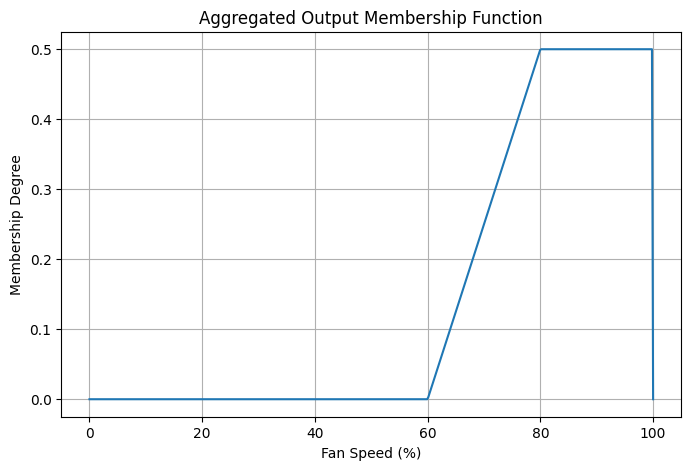

np.float64(84.39236534065448)

In [8]:
# # Plot membership functions for temperature
# plt.figure(figsize=(8, 5))
# plt.plot(temp, cold)
# plt.plot(temp, warm)
# plt.plot(temp, hot)
# plt.title("Temperature Membership Functions")
# plt.xlabel("Temperature (°C)")
# plt.ylabel("Membership Degree")
# plt.grid(True)
# plt.show()

# # Plot membership functions for fan speed
# plt.figure(figsize=(8, 5))
# plt.plot(speed, slow)
# plt.plot(speed, moderate)
# plt.plot(speed, fast)
# plt.title("Fan Speed Membership Functions")
# plt.xlabel("Fan Speed (%)")
# plt.ylabel("Membership Degree")
# plt.grid(True)
# plt.show()

# Plot aggregated output
plt.figure(figsize=(8, 5))
plt.plot(speed, aggregated)
plt.title("Aggregated Output Membership Function")
plt.xlabel("Fan Speed (%)")
plt.ylabel("Membership Degree")
plt.grid(True)
plt.show()

fan_output
